**Step 2: Data Cleaning and Preprocessing**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

#Loading all dataset one togather as it is available one step back folder used ..
_customer_df = pd.read_csv('../dataset/customers.csv')
_order_df = pd.read_csv('../dataset/orders.csv')
_order_item_df = pd.read_csv('../dataset/order_item.csv')
_location_df = pd.read_csv('../dataset/location.csv')
_payment_df = pd.read_csv('../dataset/payments.csv')
_product_df = pd.read_csv('../dataset/products.csv')
_product_cat_tr_df = pd.read_csv('../dataset/category_translation.csv')
_review_df = pd.read_csv('../dataset/reviews.csv')
_seller_df = pd.read_csv('../dataset/sellers.csv')

***Checking dupliate in customer and order table***

In [2]:
print(len(_customer_df))
print(len(_order_df))
#ordr table has empty data that is managed below at section no 137

99441
99441


**Conveting type to datetime**

In [3]:
#Conversion object to date time
_order_df['order_purchase_timestamp'] = pd.to_datetime(_order_df['order_purchase_timestamp'])
_order_df['order_approved_at'] = pd.to_datetime(_order_df['order_approved_at'])
_order_df['order_delivered_carrier_date'] = pd.to_datetime(_order_df['order_delivered_carrier_date'])
_order_df['order_delivered_customer_date'] = pd.to_datetime(_order_df['order_delivered_customer_date'])
_order_df['ord/er_estimated_delivery_date'] = pd.to_datetime(_order_df['order_estimated_delivery_date'])

#order item dataset datetime conversion
_order_item_df['shipping_limit_date'] = pd.to_datetime(_order_item_df['shipping_limit_date'])
#print(_order_item_df.info())

#review dataset datetime conversion
_review_df['review_creation_date']= pd.to_datetime(_review_df['review_creation_date'])
_review_df['review_answer_timestamp']= pd.to_datetime(_review_df['review_answer_timestamp'])
#print(_review_df.info())

***Handling missing values for order***

In [4]:
#As per analysis avg devlivery of order took 12 days make column accordingly

#Created nested disctonary for all the status, as need to fill all three feature and accordingly added time to each
fill_dates_of_status = {
    'created': {
        'order_approved_at': pd.Timedelta(minutes=30),
        'order_delivered_carrier_date': pd.Timedelta(days=5),
        'order_delivered_customer_date': pd.Timedelta(days=10)
    },
    'unavailable': {
        'order_approved_at': pd.Timedelta(minutes=30),
        'order_delivered_carrier_date': pd.Timedelta(days=5),
        'order_delivered_customer_date': pd.Timedelta(days=10)
    },
    'canceled': {
        'order_approved_at': pd.Timedelta(days=-1),
        'order_delivered_carrier_date': pd.Timedelta(days=-1),
        'order_delivered_customer_date': pd.Timedelta(days=-1)
    },
    'approved': {
        'order_approved_at': pd.Timedelta(hours=6),
        'order_delivered_carrier_date': pd.Timedelta(days=5),
        'order_delivered_customer_date': pd.Timedelta(days=10)
    },
    'shipped': {
        'order_approved_at': pd.Timedelta(hours=6),
        'order_delivered_carrier_date': pd.Timedelta(days=5),
        'order_delivered_customer_date': pd.Timedelta(days=10)
    },
    'invoiced': {
        'order_approved_at': pd.Timedelta(hours=6),
        'order_delivered_carrier_date': pd.Timedelta(days=5),
        'order_delivered_customer_date': pd.Timedelta(days=10)
    },
    'processing': {
        'order_approved_at': pd.Timedelta(hours=6),
        'order_delivered_carrier_date': pd.Timedelta(days=5),
        'order_delivered_customer_date': pd.Timedelta(days=10)
    },
    'delivered': {
        'order_approved_at': pd.Timedelta(hours=6),
        'order_delivered_carrier_date': pd.Timedelta(days=2),
        'order_delivered_customer_date': pd.Timedelta(days=9)
    }
}

for status, column_position in fill_dates_of_status.items():
    for col, val_to_replace in column_position.items():
        mask = (_order_df['order_status'] == status) & (_order_df[col].isna())
        _order_df.loc[mask, col] = _order_df['order_purchase_timestamp'] + val_to_replace

_order_df.isna().sum()


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                 0
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
ord/er_estimated_delivery_date    0
dtype: int64

**Removing duplicate from order item**

In [5]:
#verification whether the order id has any duplicate entries
##Order item has duplicate entries for the same order multiple entries remove duplicate
_order_item_df = _order_item_df.drop_duplicates(subset=['order_id'], keep='first')

#Post removal 0 deuplicate and 0 empty column
print(_order_item_df.duplicated(subset=['order_id']).sum())
print(len(_order_item_df))

0
98666


**Data cleaning feature**

**Handling missing value for the product**

In [6]:
#product has more than 600 rows for name and few more columns that need to be filled.
#print(_product_df)

print(_product_df.duplicated(subset=['product_id']).sum())
#No duplicate data
print("before managing null column values")

#filling each individual column with groupped into corresponding weight and assigning that product name to the available weight 
#same has been applied to other empty columns
_product_df['product_category_name'] = _product_df.groupby('product_weight_g')['product_category_name'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
_product_df['product_name_lenght'] = _product_df.groupby('product_category_name')['product_name_lenght'].transform(lambda x: x.fillna(x.mean()))
_product_df['product_description_lenght'] = _product_df.groupby('product_category_name')['product_description_lenght'].transform(lambda x: x.fillna(x.mean()))
_product_df['product_photos_qty'] = _product_df.groupby('product_category_name')['product_photos_qty'].transform(lambda x: x.fillna(x.mean()))

#As values are multiple fraction used floor method
_product_df['product_name_lenght'] = np.floor(_product_df['product_name_lenght'])
_product_df['product_description_lenght'] = np.floor(_product_df['product_description_lenght'])
_product_df['product_photos_qty'] = np.floor(_product_df['product_photos_qty'])

print("After managing null column values")

#At last we have 4 rows containing null rows getting dropped from the dataframe
_product_df = _product_df.dropna()
print(_product_df.isnull().sum())


0
before managing null column values
After managing null column values
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


***Data verification for empty and duplicate as well as merging with category table***

In [7]:
print(_seller_df.isna().sum())
#NO empty data on seller

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [8]:
#Merging product catogary and product table
print(len(_product_df))
print(_product_df.isna().sum()) #it has 32951 rows before introducing id column for prod_cat_id

# 1 getting cat name from both the column to validate if it contain any space that make multiple entries and data gets malformed
_product_cat_tr_df['product_category_name'] = _product_cat_tr_df['product_category_name'].str.strip()
_product_df['product_category_name'] = _product_df['product_category_name'].str.strip()

# 4 Applied iner join as number of rows mapped to cat column has to be same as it mapped to each rows
prd_cat_master = pd.merge(_product_df,_product_cat_tr_df,on='product_category_name', how='left')

#As few of the rows for the product english name not available so kept same as category name
prd_cat_master['product_category_name_english'] = prd_cat_master.apply(
    lambda master_data: master_data['product_category_name'] if pd.isna(master_data['product_category_name_english']) else master_data['product_category_name_english'], 
    axis=1
)

print(len(prd_cat_master))
#No Duplicate data


32947
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64
32947


***review dataset verification for duplicate and empty data***

In [9]:
print(f"Rows before: {len(_review_df)}")
_review_df.drop_duplicates(subset=['review_id'], keep='first', inplace=True)
print(f"Rows after: {len(_review_df)}")
_review_df['review_comment_title'] = _review_df.groupby('review_score')['review_comment_title'].transform(lambda title: title.fillna(title.mode()[0] if not title.mode().empty else 'Unknown'))
_review_df['review_comment_message'] = _review_df.groupby('review_score')['review_comment_message'].transform(lambda msg: msg.fillna(msg.mode()[0] if not msg.mode().empty else 'Unknown'))

print(_review_df.isna().sum())
#has issue with review, as same review id associated with  that can not be possbile kept one out of multiple(mostly count is 2)
#few order have no review


Rows before: 99224
Rows after: 98410
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


***Step 3: Data Integration (Critical Component) part 1***

In [10]:
customer_order = pd.merge(_order_df,_customer_df, on='customer_id', how='left')

customer_order_item = pd.merge(customer_order,_order_item_df, on='order_id', how='left')

#Dropping order item empty data and its status associated item id has no data, as its status is either unavailable or cancelled.
customer_order_item = customer_order_item.dropna()

#for some of the product that has been sold has no details in product table but data available in data item
#for that created uknown group
customer_order_item_product = pd.merge(customer_order_item,prd_cat_master, on='product_id', how='left')

#As order item and product table has data mismatch few product that are delivered is not
#available as part of product have made assumptin based on price and fright value.
customer_order_item_product['product_category_name'] = customer_order_item_product.groupby(['price','freight_value'])['product_category_name'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
customer_order_item_product['product_name_lenght'] = customer_order_item_product.groupby(['price','freight_value'])['product_name_lenght'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_description_lenght'] = customer_order_item_product.groupby(['price','freight_value'])['product_description_lenght'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_photos_qty'] = customer_order_item_product.groupby(['price','freight_value'])['product_photos_qty'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_weight_g'] = customer_order_item_product.groupby(['price','freight_value'])['product_weight_g'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_length_cm'] = customer_order_item_product.groupby(['price','freight_value'])['product_length_cm'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_height_cm'] = customer_order_item_product.groupby(['price','freight_value'])['product_height_cm'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_width_cm'] = customer_order_item_product.groupby(['price','freight_value'])['product_width_cm'].transform(lambda x: x.fillna(x.mean())).fillna(0.0)
customer_order_item_product['product_category_name_english'] = customer_order_item_product.groupby(['price','freight_value'])['product_category_name_english'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

print(customer_order_item_product.isna().sum())


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                 0
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
ord/er_estimated_delivery_date    0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
product_category_name             0
product_name_lenght               0
product_description_lenght        0
product_photos_qty                0
product_weight_g                  0
product_length_cm                 0
product_height_cm                 0
product_width_cm                  0
product_category_name_englis

***Step 3: Data Integration (Critical Component) part 2***

In [11]:
print("customer_order_item_product before merge",len(customer_order_item_product))
customer_order_item_product_pay = pd.merge(customer_order_item_product,_payment_df, on='order_id', how='left')

# customer_order_item_product_pay it has only 1 empty data, so remove from the dataframe
customer_order_item_product_pay = customer_order_item_product_pay.dropna()
print("customer_order_item_product_pay ",len(customer_order_item_product_pay),"\n")


customer_order_item_product_review = pd.merge(customer_order_item_product_pay,_review_df, on='order_id', how='left')
print(" customer_order_item_product_review length before process start",len(customer_order_item_product_review),"\n")

#multiple order has no review creating fake review based on fright value and price
#created proxy review_id with length 32 end 8 digit is unique id and statrting 24 is 0 for the missing review
customer_order_item_product_review['review_id'] = [format(x, '032x') for x in np.random.randint(0, 0xFFFFFFFF, size=len(customer_order_item_product_review))]

#Based product catogery and weight find review score and filled in the score column
customer_order_item_product_review['review_score'] = customer_order_item_product_review.groupby(['product_category_name','product_width_cm'])['review_score'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 1))

#hard coded comment 
customer_order_item_product_review['review_comment_title'] = customer_order_item_product_review['review_comment_title'].fillna('recomendo')
customer_order_item_product_review['review_comment_message'] = customer_order_item_product_review['review_comment_message'].fillna('foi bom')

#Added review creation date as order delivered date +1
customer_order_item_product_review['review_creation_date'] = customer_order_item_product_review['review_creation_date'].fillna(customer_order_item_product_review['order_delivered_customer_date']+pd.Timedelta(days=1))

#Added review answered date as order delivered date +2
customer_order_item_product_review['review_answer_timestamp'] = customer_order_item_product_review['review_answer_timestamp'].fillna(customer_order_item_product_review['order_delivered_customer_date']+pd.Timedelta(days=2))

#Handeld all the missing case
customer_orderitem_product_seller = pd.merge(customer_order_item_product_review,_seller_df, on='seller_id', how='left')
print(f"length of customer_orderitem_product_seller post merge before process {len(customer_orderitem_product_seller)}")

#after making master data set checked for duplicate as have applied impute method so there might be case of duplication
customer_orderitem_product_seller = customer_orderitem_product_seller.drop_duplicates(subset=['order_id','customer_id','product_id'], keep='first')
print(len(customer_orderitem_product_seller.loc[customer_orderitem_product_seller.duplicated(subset=['order_id','customer_id'],keep=False)]))
print(customer_orderitem_product_seller.isna().sum())



customer_order_item_product before merge 98666
customer_order_item_product_pay  103056 

 customer_order_item_product_review length before process start 103325 

length of customer_orderitem_product_seller post merge before process 103325
0
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                 0
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
ord/er_estimated_delivery_date    0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
product_category_name             0
product_name_lenght               0
pro

**Step 4 Feature Engineering**

In [12]:
#Total order value (aggregated from order_items or payments) 
total_order_value = customer_orderitem_product_seller['price'].sum()
print(f"Total order value : {total_order_value}")

#Delivery time (order purchase to delivery date)
customer_orderitem_product_seller['delivery_time_days'] = (customer_orderitem_product_seller['order_delivered_customer_date'] - customer_orderitem_product_seller['order_purchase_timestamp']).dt.days
print(f"Delivery time (order purchase to delivery date) :  {customer_orderitem_product_seller['delivery_time_days'].mean():.2f}")

#Customer purchase frequency
# Calculate Totals
total_revenue = customer_orderitem_product_seller['price'].sum() + customer_orderitem_product_seller['freight_value'].sum()
total_orders = customer_orderitem_product_seller['order_id'].nunique()
total_customers = customer_orderitem_product_seller['customer_unique_id'].nunique()
purchase_frequency = total_orders / total_customers
print(f"total_orders :{total_orders}")
print(f"total_customers : {total_customers}")
print(f"total_revenue : {total_revenue}")
print(f"purchase_frequency : {purchase_frequency:.2f} ")
print(f"purchase_frequency { purchase_frequency} mean the customer who bought one never gets returend to the platform \n")
#ration 1.03 means we have received 100 customer 103 order

#Customer lifetime value initial data extraction
customer_dates = customer_orderitem_product_seller.groupby('customer_unique_id')['order_purchase_timestamp'].agg(['min','max'])
customer_dates['life_span_year'] = (customer_dates['max']- customer_dates['min']).dt.days/365
customer_life_span_ = customer_dates['life_span_year'].mean()
print(f"customer_life_span_ : {customer_life_span_}")

#Average order value per customer
aov = total_revenue/total_orders
print(f"Average order value per customer : {aov} \n")

#Customer lifetime value
cust_lifetime_value = aov * purchase_frequency * customer_life_span_
print(f"Customer lifetime value { cust_lifetime_value }")
#0.007321393013969964 measn 0.007321393013969964*365 = 2.7 days we got this number means start and end date are near
#Once the customer buys never return

Total order value : 12428351.320000002
Delivery time (order purchase to delivery date) :  12.00
total_orders :98665
total_customers : 95419
total_revenue : 14421591.8
purchase_frequency : 1.03 
purchase_frequency 1.034018382083233 mean the customer who bought one never gets returend to the platform 

customer_life_span_ : 0.007321393013969964
Average order value per customer : 146.16725079815538 

Customer lifetime value 1.1065525886337786


**Step 5: Exploratory Data Analysis (EDA)**

***Customer Analysis***

**Geographic distribution of customers as well avg earning from the geographical**

                       customer_unique_id       price  avg_rev_per_cust
customer_city                                                          
sao paulo                           14865  1732814.95        116.570128
rio de janeiro                       6576   898873.83        136.690059
belo horizonte                       2654   330460.23        124.514028
brasilia                             2056   278226.51        135.324178
curitiba                             1455   192036.67        131.983966
campinas                             1386   171568.06        123.786479
porto alegre                         1320   167751.15        127.084205
salvador                             1202   161819.60        134.625291
guarulhos                            1143   131828.67        115.335669
sao bernardo do campo                 898    96248.96        107.181470


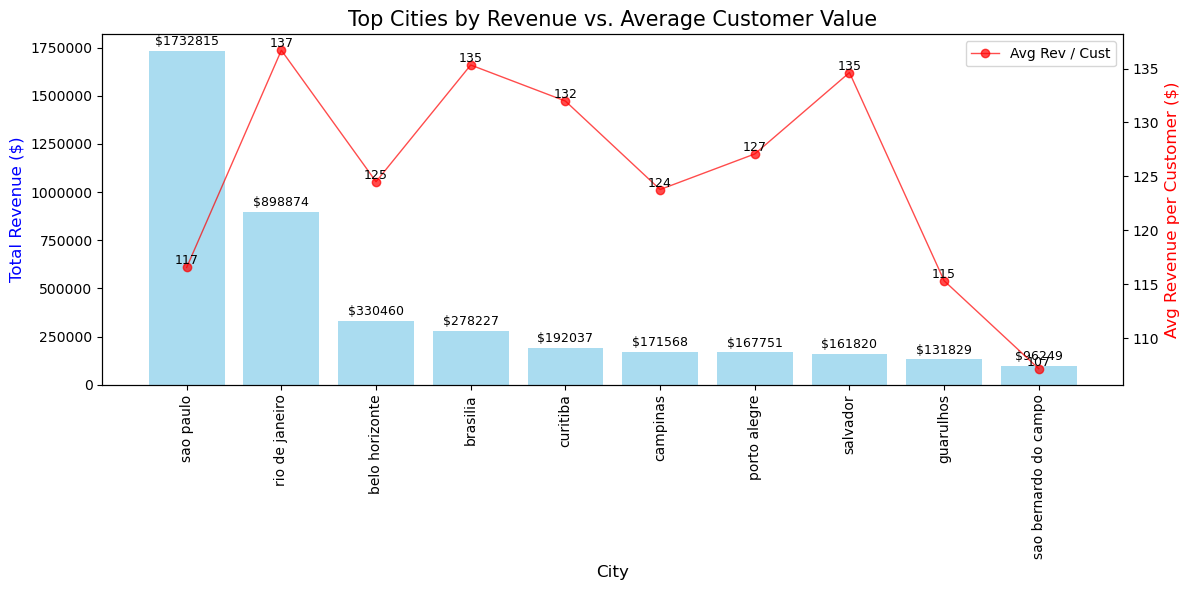

In [13]:
#Geographic distribution of customers as grouped each customer has groupped into their corresponding city
geography_dist = customer_orderitem_product_seller.groupby('customer_city').agg({'customer_unique_id':'nunique','price':'sum'})
geography_dist['avg_rev_per_cust'] =  geography_dist['price']/ geography_dist['customer_unique_id']

geography_dist = geography_dist.sort_values(by='customer_unique_id', ascending=False)
print(geography_dist.head(10))

#Taking only top 10
geography_dist = geography_dist.head(10)
fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(geography_dist.index, geography_dist['price'], color='skyblue', alpha=0.7, label='Total Revenue')
ax1.ticklabel_format(style='plain', axis='y')
ax1.set_ylabel('Total Revenue ($)', fontsize=12, color='blue')
ax1.set_xlabel('City', fontsize=12)
plt.xticks(rotation=90)
ax1.bar_label(bars, fmt='$%.0f', padding=2, fontsize=9)

#Making use of twin that share x axis as we want to compare 2 data at on 1-to-go
ax2 = ax1.twinx()
ax2.plot(geography_dist.index, geography_dist['avg_rev_per_cust'], color='red', marker='o',alpha=0.7, linewidth=1, label='Avg Rev / Cust')
ax2.set_ylabel('Avg Revenue per Customer ($)', fontsize=12, color='red')

#To add lable in the line point need to use axs.text and based on the horizantal and veritcal point the labels.
for x, y in enumerate(geography_dist['avg_rev_per_cust']):
    ax2.text(x, y, f'{y:,.0f}', # f-string adds commas and removes decimals
            ha='center',       # horizontal alignment
            va='bottom',       # vertical alignment (sits on top of the dot)
            fontsize=9,
            color='black')
plt.title('Top Cities by Revenue vs. Average Customer Value', fontsize=15)
#plt.xticks(rotation=90)
fig.tight_layout()

plt.legend()
plt.show()

**New vs repeat customers**

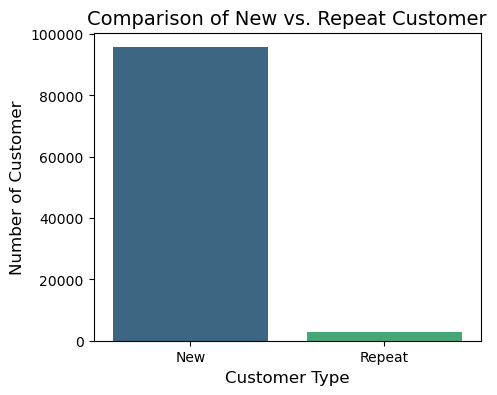

In [14]:
#New vs repeat customers 
customer_orderitem_product_seller['starting_purchase'] = customer_orderitem_product_seller.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min');
def repreate_or_new_customer(ecommerce_data):
    if ecommerce_data['starting_purchase'] == ecommerce_data['order_purchase_timestamp']:
        return "New"
    else:
        return "Repeat"

customer_orderitem_product_seller['customer_type'] = customer_orderitem_product_seller.apply(repreate_or_new_customer, axis=1)

customer_counts = customer_orderitem_product_seller['customer_type'].value_counts()

plt.figure(figsize=(5, 4))
sns.barplot(x=customer_counts.index, y=customer_counts.values, palette='viridis', hue=customer_counts.index)

# 3. Add labels and title
plt.title('Comparison of New vs. Repeat Customer', fontsize=14)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Number of Customer', fontsize=12)

plt.show()

**High-value vs low-value customers**

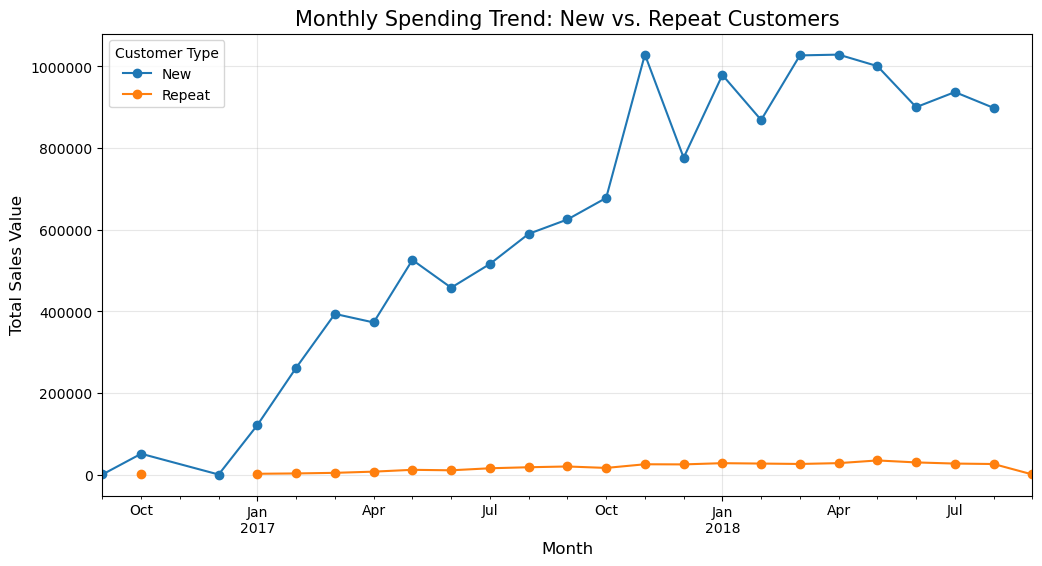

In [15]:
customer_orderitem_product_seller['customer_spend_value'] = customer_orderitem_product_seller['price'] + customer_orderitem_product_seller['freight_value']

def categoris_spending(ecommerce_data):
    if ecommerce_data['customer_spend_value'] >=300:
        return "High"
    elif ecommerce_data['customer_spend_value'] >= 50 and ecommerce_data['customer_spend_value'] <= 300:
        return "Medium"
    else:
        return "Low"

customer_orderitem_product_seller['customer_spend_type'] = customer_orderitem_product_seller.apply(categoris_spending, axis=1)

##making config
customer_orderitem_product_seller['order_purchase_timestamp'] = pd.to_datetime(customer_orderitem_product_seller['order_purchase_timestamp'])
customer_orderitem_product_seller['month_year'] = customer_orderitem_product_seller['order_purchase_timestamp'].dt.to_period('M')

# 2. Group by Month and Customer Type, then sum the spending
trend_data = customer_orderitem_product_seller.groupby(['month_year', 'customer_type'])['customer_spend_value'].sum().unstack()

trend_data = trend_data.sort_values(by='month_year',ascending=False)
# 3. Plotting the line chart
ax = trend_data.plot(kind='line', marker='o', figsize=(12, 6))
ax.ticklabel_format(style='plain', axis='y')
plt.title('Monthly Spending Trend: New vs. Repeat Customers', fontsize=15)
plt.ylabel('Total Sales Value', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Customer Type')
plt.show()

***Revenue and Order Analysis***

**Monthly revenue trends**

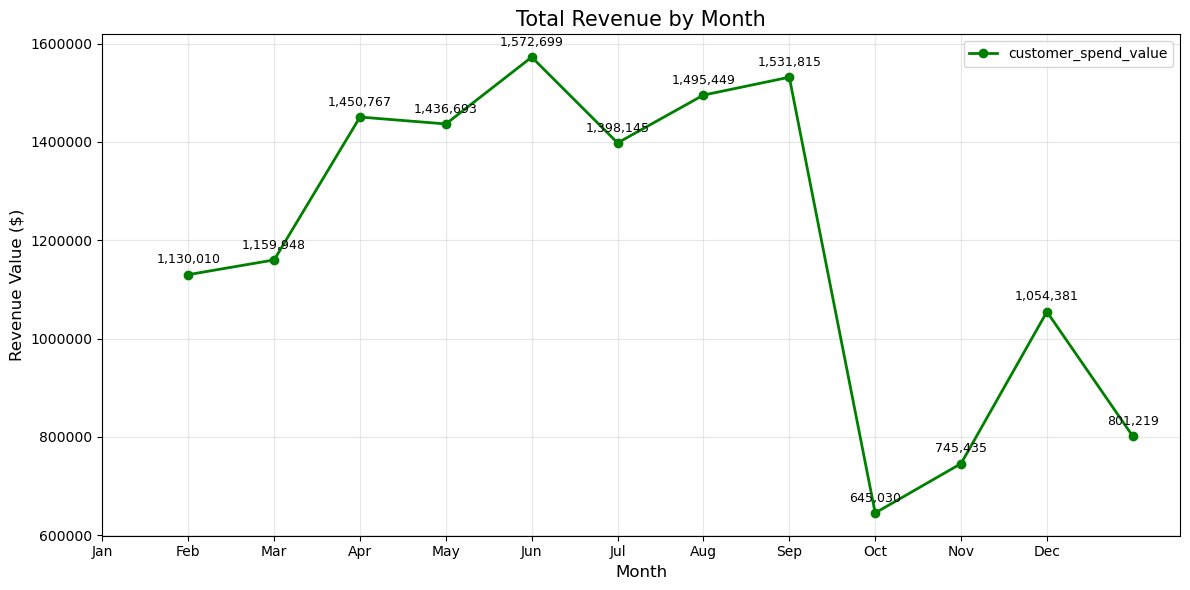

In [16]:
months_for_volumn_trend = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue = customer_orderitem_product_seller.groupby(customer_orderitem_product_seller['order_purchase_timestamp'].dt.month)['customer_spend_value'].sum()                                                                                                                                                                                                                                        

plt.figure(figsize=(12, 6))
ax = monthly_revenue.plot(kind='line', marker='o', color='green', linewidth=2)
ax.ticklabel_format(style='plain', axis='y')
ax.set_xticks(range(12)) 
ax.set_xticklabels(months_for_volumn_trend)

# Manually add labels for a LINE chart
#For exact data point applied annotate
for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    ax.annotate(f'{y:,.0f}', 
                xy=(x, y),        
                xytext=(0, 6),      
                textcoords='offset points', 
                ha='center',         
                va='bottom',        
                fontsize=9)

plt.title('Total Revenue by Month', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue Value ($)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


**Order volume trends**

yearly_volumn_trand 
 order_purchase_timestamp
2016      311
2017    44579
2018    53775
Name: order_id, dtype: int64
monthly_volumn_trand 
 order_purchase_timestamp
1      8009
2      8427
3      9829
4      9325
5     10513
6      9377
7     10242
8     10745
9      4246
10     4876
11     7451
12     5625
Name: order_id, dtype: int64


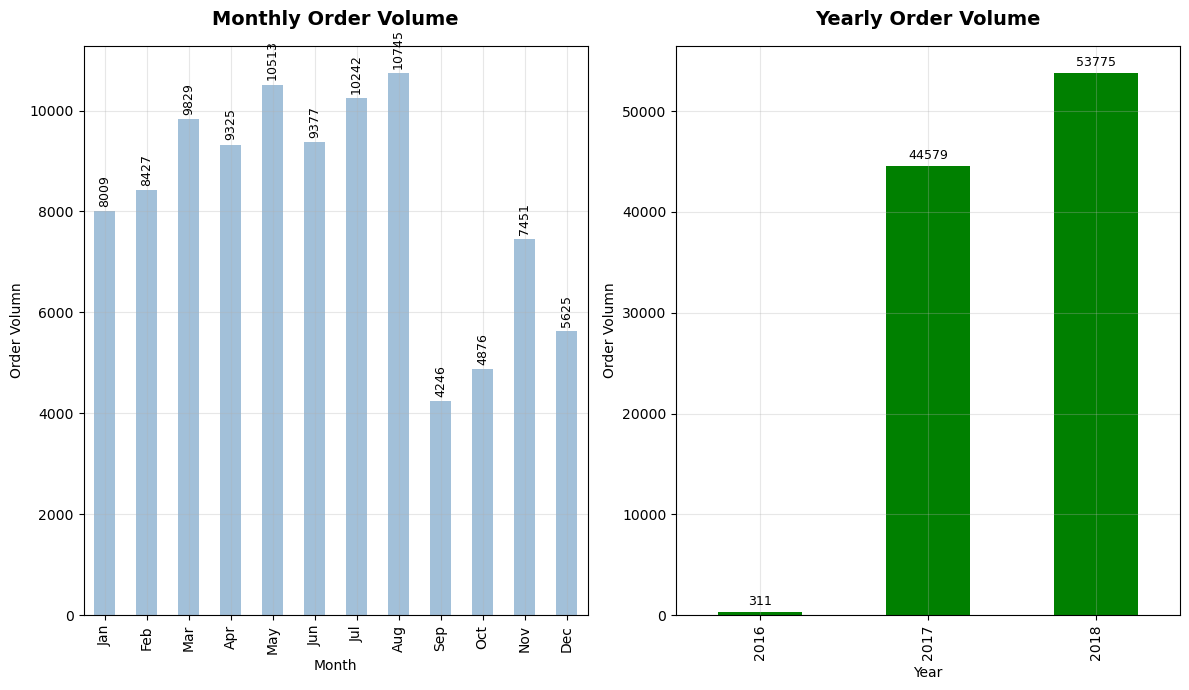

In [17]:
yearly_volumn_trand = customer_orderitem_product_seller.groupby(customer_orderitem_product_seller['order_purchase_timestamp'].dt.year)['order_id'].count()
monthly_volumn_trand = customer_orderitem_product_seller.groupby(customer_orderitem_product_seller['order_purchase_timestamp'].dt.month)['order_id'].count()
print(f"yearly_volumn_trand \n {yearly_volumn_trand}")
print(f"monthly_volumn_trand \n {monthly_volumn_trand}")

#Create subplot to display montly as well as yearly order volumn
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12, 7))

#ax1 monthly order volumn
ax1 = monthly_volumn_trand.plot(kind='bar', color='steelblue', linewidth=2, ax = ax1, alpha=0.5)
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Volumn')
ax1.set_xticks(range(12)) 
ax1.set_xticklabels(months_for_volumn_trend)
ax1.bar_label(ax1.containers[0], padding=3, fontsize=9,rotation=90)
ax1.grid(True, alpha=0.3)
ax1.set_title("Monthly Order Volume", fontsize=14, fontweight='bold', pad=15)

#ax1 yearly order volumn
ax2 = yearly_volumn_trand.plot(kind='bar', color='green', linewidth=2, ax = ax2)
ax2.bar_label(ax2.containers[0], padding=3, fontsize=9)
ax2.set_xlabel('Year')
ax2.set_ylabel('Order Volumn')
ax2.grid(True, alpha=0.3)
ax2.set_title("Yearly Order Volume", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Peak sales periods**

8876.0
7


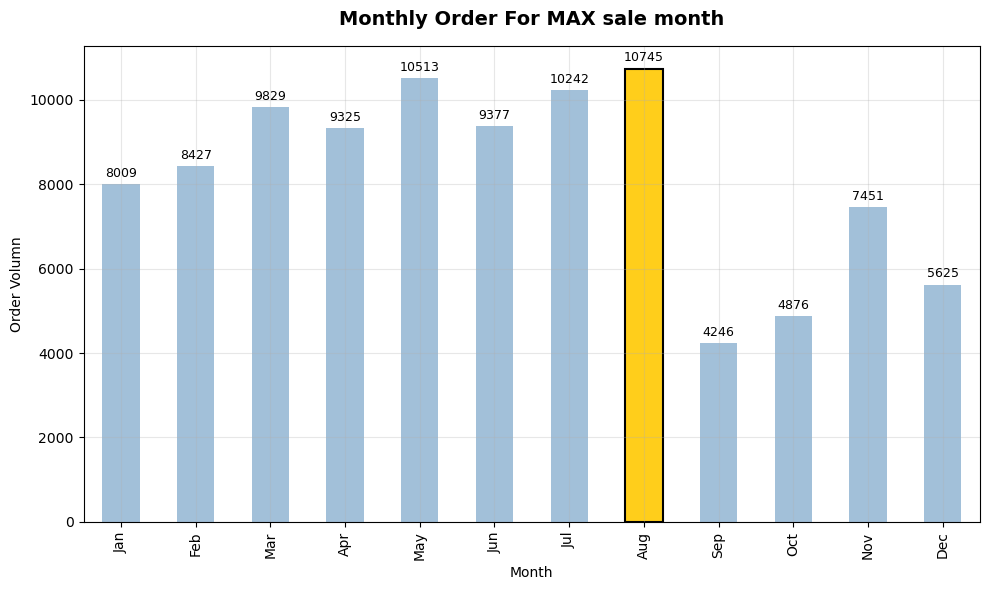

In [30]:
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

peak_sales_order = customer_orderitem_product_seller.groupby(customer_orderitem_product_seller['order_purchase_timestamp'].dt.month)['order_id'].count()
fig, maxsale = plt.subplots(figsize=(10,6))

maxsale = monthly_volumn_trand.plot(kind='bar', color='steelblue', linewidth=2, ax = maxsale, alpha=0.5)

# Option A: Dynamically find the highest bar index
highlight_index = peak_sales_order.values.argmax()
print(highlight_index)
target_bar = maxsale.containers[0][highlight_index]
target_bar.set_color("#FFCE1B")  
target_bar.set_alpha(1.0)  
target_bar.set_edgecolor("black")
target_bar.set_linewidth(1.5)
maxsale.set_xlabel('Month')
maxsale.set_ylabel('Order Volumn')
maxsale.set_xticks(range(12))

#mapping month numbers with label
monthly_volumn_trand.index = monthly_volumn_trand.index.map(month_map)
maxsale.set_xticklabels(months_for_volumn_trend)
maxsale.bar_label(maxsale.containers[0], padding=3, fontsize=9,rotation=0)
maxsale.grid(True, alpha=0.3)
maxsale.set_title("Monthly Order For MAX sale month", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

***Product Analysis***

**Top-selling product categories**

top selling products
                               order_id       price
product_category_name_english                      
health_beauty                      8861  1199703.59
watches_gifts                      5644  1169365.49
sports_leisure                     8137   961471.58
bed_bath_table                     9657   937647.23
computers_accessories              6669   780308.10
furniture_decor                    6474   620783.79
cool_stuff                         3608   615937.89
housewares                         5853   567470.61
auto                               3908   566235.36
toys                               3862   464791.55


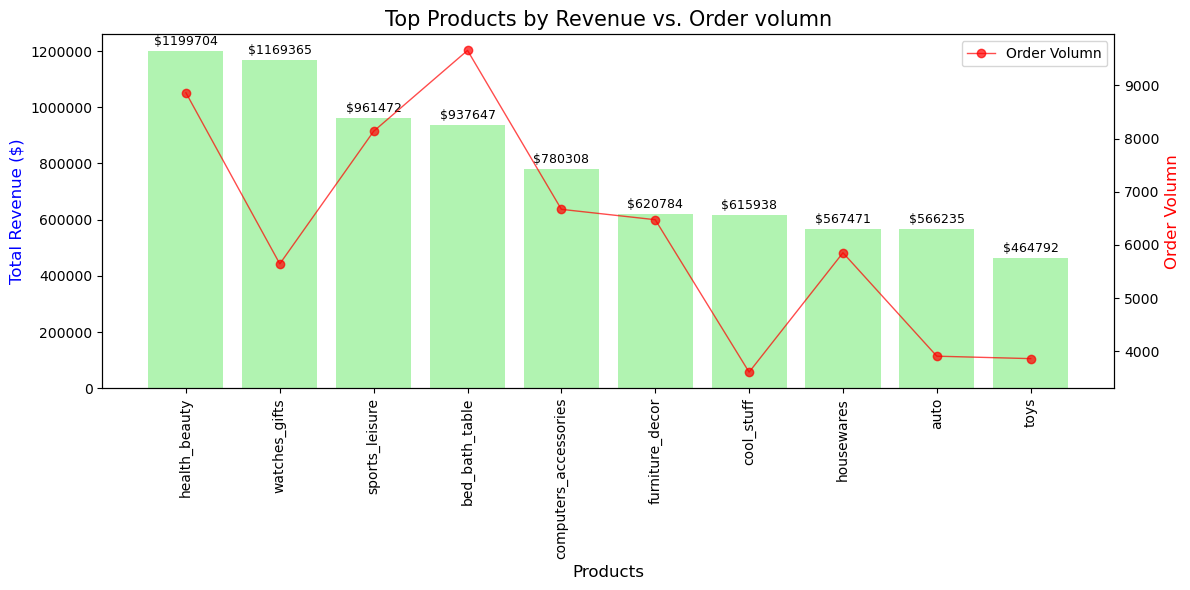

In [31]:
max_selling_product = customer_orderitem_product_seller.groupby('product_category_name_english').agg({
    'order_id': 'count',
    'price': 'sum'
})

max_selling_product = max_selling_product.sort_values(by='price', ascending=False).head(10)
max_selling_product['price'] = max_selling_product['price'].round(2)

print("top selling products")
print(max_selling_product)

fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(max_selling_product.index, max_selling_product['price'], color='lightgreen', alpha=0.7, label='Total Revenue')
ax1.set_ylabel('Total Revenue ($)', fontsize=12, color='blue')
ax1.set_xlabel('Products', fontsize=12)
plt.xticks(rotation=90)
ax1.bar_label(bars, fmt='$%.0f', padding=2, fontsize=9)
ax1.ticklabel_format(style='plain', axis='y')


#Making use of twin that share x axis as we want to compare 2 data at on 1-to-go
ax2 = ax1.twinx()
ax2.plot(max_selling_product.index, max_selling_product['order_id'], color='red', marker='o',alpha=0.7, linewidth=1, label='Order Volumn')

'''for x, y in enumerate(max_selling_product['order_id']):
    ax2.text(x, y, f'{y:,.0f}',
            ha='center',       
            va='bottom',     ##removed label for lines marker value as it gives cumbersom output
            fontsize=9,
            color='black')'''
ax2.set_ylabel('Order Volumn', fontsize=12, color='red')
plt.title('Top Products by Revenue vs. Order volumn', fontsize=15)
fig.tight_layout()

plt.legend()
plt.show()


**Revenue contribution by category**

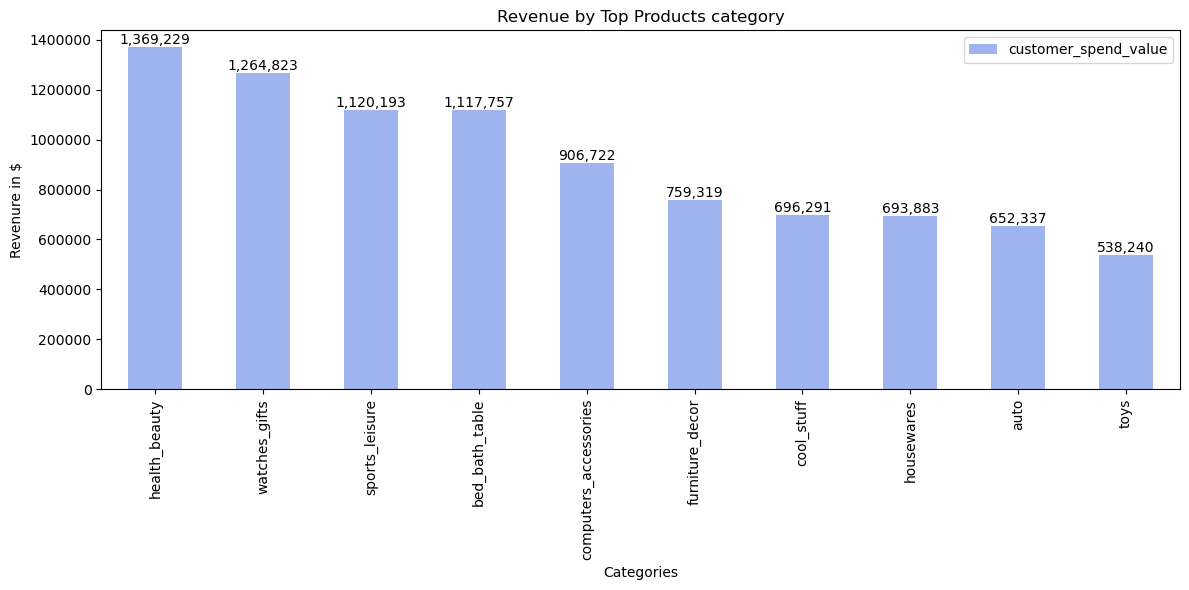

In [32]:
revenue_contribution = customer_orderitem_product_seller.groupby('product_category_name_english')['customer_spend_value'].sum()
revenue_contribution.columns = ['Category', 'spend_value']
revenue_contribution = revenue_contribution.sort_values(ascending=False)
revenue_contribution = revenue_contribution.head(10)

plt.figure(figsize=(12, 6))

ax = revenue_contribution.plot(kind='bar',color='royalblue', linewidth=2, alpha=0.5)
ax.ticklabel_format(style='plain', axis='y')
ax.bar_label(ax.containers[0],fmt='{:,.0f}')

plt.title("Revenue by Top Products category")
plt.xlabel("Categories")
plt.ylabel("Revenure in $")

plt.legend()
plt.tight_layout()
plt.show()

**Product demand distribution**

In [33]:
#total demand
product_selling = customer_orderitem_product_seller.groupby('product_category_name')['order_id'].count().sort_values(ascending=False)
product_selling = product_selling.reset_index()
product_selling.columns= ['Category', 'total_orders']

#create distribution
total_orders_all_cat = product_selling['total_orders'].sum()
print(total_orders_all_cat)
product_selling['Percentage'] = ((product_selling['total_orders'] / total_orders_all_cat) * 100).round(2)
product_selling.head(10)

98665


,Category,total_orders,Percentage
0,cama_mesa_banho,9657,9.79
1,beleza_saude,8861,8.98
2,esporte_lazer,8137,8.25
3,informatica_acessorios,6669,6.76
4,moveis_decoracao,6474,6.56
5,utilidades_domesticas,5853,5.93
6,relogios_presentes,5644,5.72
7,telefonia,4270,4.33
8,automotivo,3908,3.96
9,brinquedos,3862,3.91


***Seller Analysis***

**Top-performing sellers**

In [34]:
top_seller_by_count = customer_orderitem_product_seller.groupby('seller_id')['order_id'].count().sort_values(ascending=False)
top_seller_by_count = top_seller_by_count.reset_index()

top_seller_by_count.columns= ['Seller', 'item_sold']
total_orders = top_seller_by_count['item_sold'].sum()
top_seller_by_count['percentage'] =((top_seller_by_count['item_sold']/total_orders)*100).round(2)
print(len(top_seller_by_count))
top_seller_by_count.head(10)

3088


,Seller,item_sold,percentage
0,6560211a19b47992c3666cc44a7e94c0,1844,1.87
1,4a3ca9315b744ce9f8e9374361493884,1760,1.78
2,cc419e0650a3c5ba77189a1882b7556a,1703,1.73
3,1f50f920176fa81dab994f9023523100,1389,1.41
4,da8622b14eb17ae2831f4ac5b9dab84a,1298,1.32
5,955fee9216a65b617aa5c0531780ce60,1281,1.30
6,7a67c85e85bb2ce8582c35f2203ad736,1150,1.17
7,ea8482cd71df3c1969d7b9473ff13abc,1136,1.15
8,4869f7a5dfa277a7dca6462dcf3b52b2,1125,1.14
9,3d871de0142ce09b7081e2b9d1733cb1,1068,1.08


**Seller contribution to revenue**

In [35]:
top_seller_by_revenue = customer_orderitem_product_seller.groupby('seller_id')['customer_spend_value'].sum().sort_values(ascending=False)
top_seller_by_revenue = top_seller_by_revenue.reset_index()
top_seller_by_revenue.columns = ['seller','contribution']

total_revenue = top_seller_by_revenue['contribution'].sum()
top_seller_by_revenue['percentage'] = ((top_seller_by_revenue['contribution']/total_revenue)*100).round(2)

print(f"total_revenue : {(total_revenue).round(2)}")
top_seller_by_revenue.head(20)

total_revenue : 14421591.8


,seller,contribution,percentage
0,4869f7a5dfa277a7dca6462dcf3b52b2,243958.76,1.69
1,53243585a1d6dc2643021fd1853d8905,219949.85,1.53
2,4a3ca9315b744ce9f8e9374361493884,210638.32,1.46
3,fa1c13f2614d7b5c4749cbc52fecda94,202394.22,1.40
4,7e93a43ef30c4f03f38b393420bc753a,181187.33,1.26
5,7c67e1448b00f6e969d365cea6b010ab,175724.62,1.22
6,7a67c85e85bb2ce8582c35f2203ad736,159982.28,1.11
7,da8622b14eb17ae2831f4ac5b9dab84a,152842.62,1.06
8,6560211a19b47992c3666cc44a7e94c0,140053.43,0.97
9,955fee9216a65b617aa5c0531780ce60,138418.11,0.96


**Seller distribution**

In [36]:
sellers = customer_orderitem_product_seller['seller_id'].value_counts()

# Percentage of total orders
seller_share = (customer_orderitem_product_seller['seller_id'].value_counts(normalize=True) * 100).round(2)

print(seller_share)
seller_revenue = customer_orderitem_product_seller.groupby('seller_id')['customer_spend_value'].sum().sort_values(ascending=False)

cumulative_rev = seller_revenue.cumsum() / seller_revenue.sum()
cumulative_rev[cumulative_rev <= 0.80].sort_values(ascending=False)

seller_id
6560211a19b47992c3666cc44a7e94c0    1.87
4a3ca9315b744ce9f8e9374361493884    1.78
cc419e0650a3c5ba77189a1882b7556a    1.73
1f50f920176fa81dab994f9023523100    1.41
da8622b14eb17ae2831f4ac5b9dab84a    1.32
                                    ... 
2d8cfba3fcd3170555941605edaa196a    0.00
9ef932e837d8b7f392c0bfee9d359dc2    0.00
72c73be2b085b9d57650dd53eb2004c9    0.00
a72f15980dc3e9bfd1a49ac9b2f3af65    0.00
ede2977fbaf3738583170735ca403f6c    0.00
Name: proportion, Length: 3088, dtype: float64


seller_id
2a7dc43cecabf23403078e2188437d1d    0.799996
dbd66278cbfe1aa1000f90a217ca4695    0.799614
cc3d14116804f7209f3884f6367f1152    0.799230
e06f09ec0a4aca210779cf1cfc63cf19    0.798846
3340ef1913fb70d28420f6ceb685c339    0.798462
                                      ...   
7e93a43ef30c4f03f38b393420bc753a    0.073371
fa1c13f2614d7b5c4749cbc52fecda94    0.060808
4a3ca9315b744ce9f8e9374361493884    0.046773
53243585a1d6dc2643021fd1853d8905    0.032168
4869f7a5dfa277a7dca6462dcf3b52b2    0.016916
Name: customer_spend_value, Length: 552, dtype: float64

***Review and Satisfaction Analysis***

**Distribution of review scores**

review_score
1.0    10.88
2.0     3.09
3.0     8.14
4.0    19.21
5.0    58.68
Name: proportion, dtype: float64


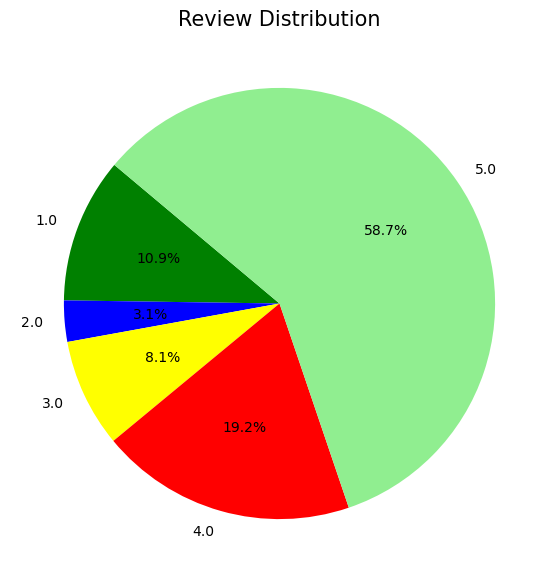

In [37]:
score_count = customer_orderitem_product_seller['review_score'].value_counts().sort_index()
score_percentage = (customer_orderitem_product_seller['review_score'].value_counts(normalize=True).sort_index() * 100).round(2)
print(score_percentage)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(score_percentage,
      labels=score_percentage.index,
      colors=['green', 'blue', 'yellow', 'red','lightgreen'],
      autopct='%1.1f%%',
      startangle=140)

ax.set_title("Review Distribution", fontsize=15)

plt.show()

**Relationship between delivery time and ratings**

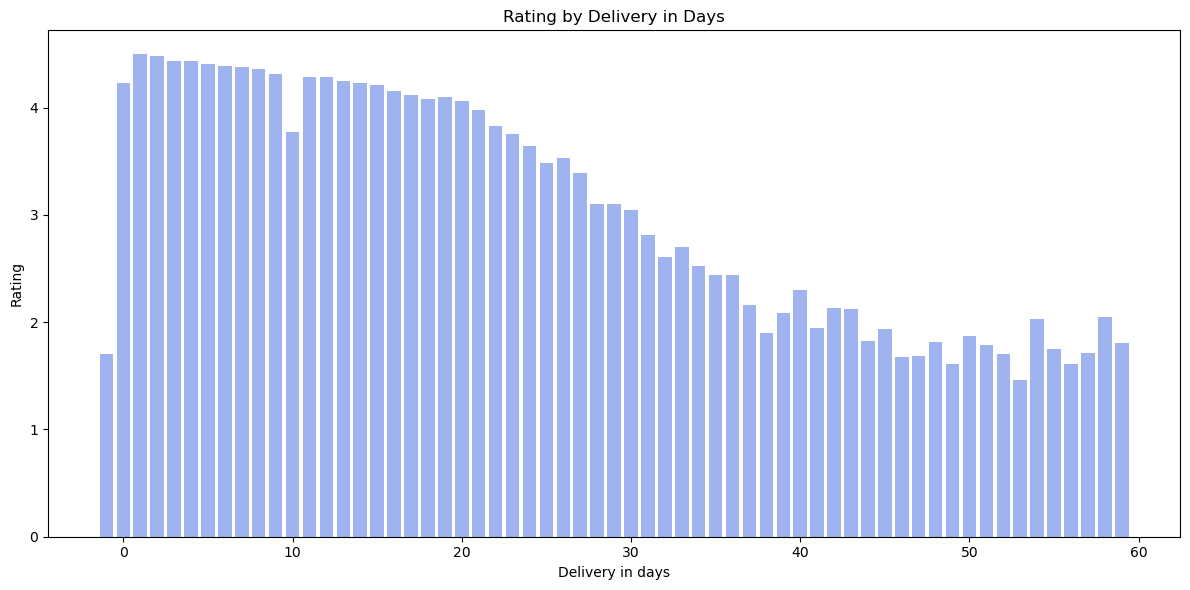

In [38]:
customer_orderitem_product_seller['delivery_time'] = (
    customer_orderitem_product_seller['order_delivered_customer_date'] - 
    customer_orderitem_product_seller['order_purchase_timestamp']
).dt.days

delivery_trend = customer_orderitem_product_seller.groupby('delivery_time')['review_score'].mean().reset_index()

# Renaming for clarity
delivery_trend.columns = ['days_to_deliver', 'avg_rating']
delivery_trend = delivery_trend.loc[delivery_trend['days_to_deliver'] < 60].sort_values(by='avg_rating',ascending=False)
delivery_trend

plt.figure(figsize=(12,6))

ax = plt.bar(delivery_trend['days_to_deliver'],delivery_trend['avg_rating'],color='royalblue', linewidth=2, alpha=0.5 )
plt.title("Rating by Delivery in Days")
plt.ylabel("Rating")
plt.xlabel("Delivery in days")

plt.tight_layout()
plt.show()

**Identification of dissatisfaction patterns**

In [39]:
dissatisfaction_by_delivery = delivery_trend.sort_values(by='avg_rating')
print("dissatisfaction_by_delivery")
print(dissatisfaction_by_delivery.head(10))
dissatisfaction_by_cat = customer_orderitem_product_seller.groupby('product_category_name')['review_score'].mean().reset_index()
dissatisfaction_by_cat.columns = ['Category','rating']
dissatisfaction_by_cat = dissatisfaction_by_cat.sort_values(by='rating',ascending=True)
print("\n dissatisfaction_by_cat")
print(dissatisfaction_by_cat.head(10))
dissatisfaction_by_seller = customer_orderitem_product_seller.groupby('seller_id')['review_score'].mean().reset_index()
dissatisfaction_by_seller.columns = ['seller','rating']
dissatisfaction_by_seller = dissatisfaction_by_seller.sort_values(by='rating',ascending=True)
print("\n dissatisfaction_by_seller")
dissatisfaction_by_seller.head(10)

dissatisfaction_by_delivery
    days_to_deliver  avg_rating
54               53    1.459459
50               49    1.606061
57               56    1.611111
47               46    1.677419
48               47    1.688312
53               52    1.702703
0                -1    1.705495
58               57    1.708333
56               55    1.750000
52               51    1.788462

 dissatisfaction_by_cat
                                         Category    rating
68                             seguros_e_servicos  2.500000
61                                       pc_gamer  3.428571
66  portateis_cozinha_e_preparadores_de_alimentos  3.428571
56                              moveis_escritorio  3.638231
37                         fashion_roupa_feminina  3.692308
39                        fashion_roupa_masculina  3.696429
43                                fraldas_higiene  3.740741
8                                           audio  3.852601
53                      moveis_colchao_e_estofado  3.86

,seller,rating
1344,6e85dc5ecd97a61094b89b046a509d8e,1.0
3083,ffcfefa19b08742c5d315f2791395ee5,1.0
1626,8501d82f68d23148b6d78bb7c4a42037,1.0
1640,8629a7efec1aab257e58cda559f03ba7,1.0
2771,e628d4a53c109f09ca88098338b3a3f5,1.0
2779,e6ffc9ac6a7adc9d16a1cfc2286dd546,1.0
1871,9a208dee8f95cfdf00760c4d627828ec,1.0
759,4003520d80d0bad1d5623f7aa3c63cda,1.0
765,40536e7ca18e1bce252828e5876466cc,1.0
1839,96f7c797de9ca20efbe14545bed63eec,1.0


***Step 6: Data Visualization**

**Time series plots (sales trends)** 


<function matplotlib.pyplot.show(close=None, block=None)>

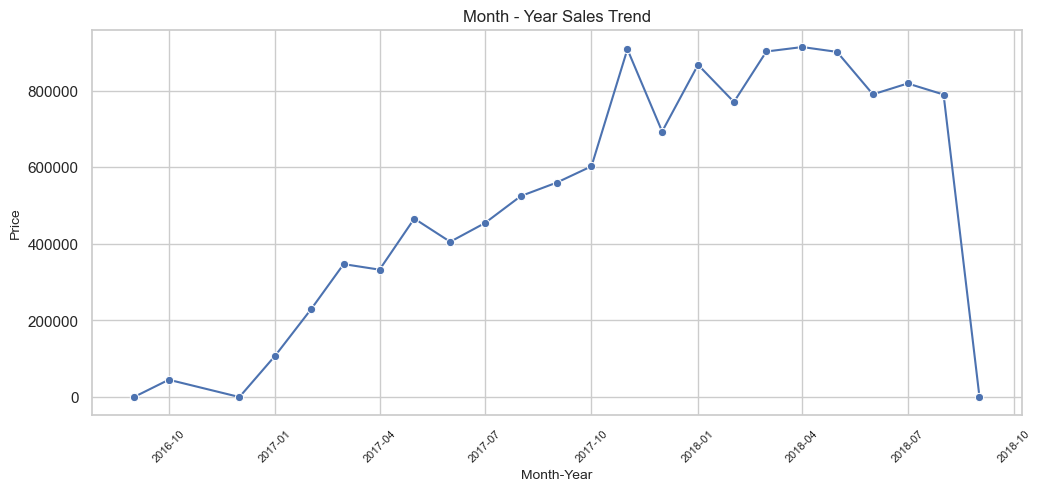

In [40]:
#it gives data based on the month regardless to the year
monthly_trends = customer_orderitem_product_seller.groupby(customer_orderitem_product_seller['order_purchase_timestamp'].dt.to_period('M'))['price'].sum().reset_index()
monthly_trends['order_purchase_timestamp'] = monthly_trends['order_purchase_timestamp'].dt.to_timestamp()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
plot = sns.lineplot(data=monthly_trends,x='order_purchase_timestamp',y='price',marker='o', color='b')
plt.title('Month - Year Sales Trend', fontsize=12)
plt.xlabel('Month-Year', fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.ylabel('Price',fontsize=10)
plt.show


**Bar charts (category performance)**

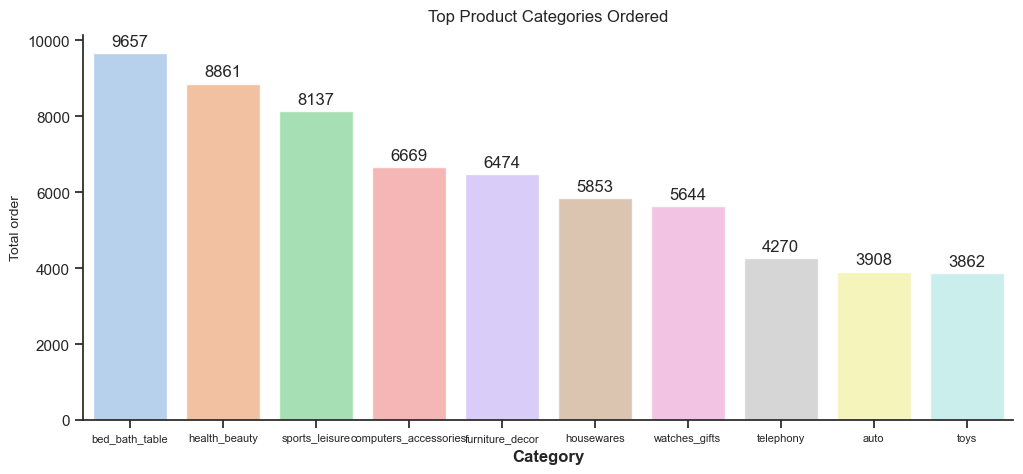

In [41]:
cat_perfomance_order = customer_orderitem_product_seller.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).reset_index()
cat_perfomance_order.columns= ['Category', 'total_orders']
top_categories_ordered = cat_perfomance_order.head(10)

sns.set_theme(style="ticks")
plt.figure(figsize=(12, 5))

plot = sns.barplot(data=top_categories_ordered,x='Category', y='total_orders', palette='pastel',hue='Category',alpha=0.85)

#Adding label to each bar as normal plot will be possible with single argument 
#Sea born provide more control over manipulation
for container in plot.containers:
    plot.bar_label(container, padding=3)
    
plt.title('Top Product Categories Ordered', fontsize=12, pad=10)
plt.ylabel('Total order', fontsize=10)
plt.xlabel('Category',fontsize=12, fontweight='bold')
plt.xticks(fontsize=8)
sns.despine()

plt.show()



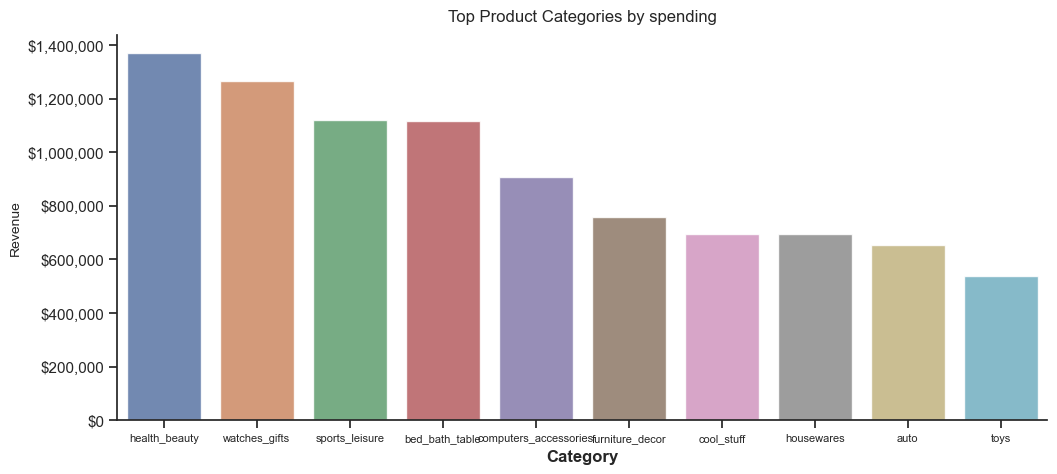

In [42]:
cat_perfomance_revenue = customer_orderitem_product_seller.groupby('product_category_name_english')['customer_spend_value'].sum().sort_values(ascending=False).reset_index()
top_categories = cat_perfomance_revenue.head(10)

sns.set_theme(style="ticks")
plt.figure(figsize=(12, 5))

plot = sns.barplot(data=top_categories,x='product_category_name_english', y='customer_spend_value', palette='deep',hue='product_category_name_english',alpha=0.85)
plt.title('Top Product Categories by spending', fontsize=12, pad=10)
plt.ylabel('Revenue', fontsize=10)
plt.xlabel('Category',fontsize=12, fontweight='bold')
plt.xticks(fontsize=8)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
sns.despine()

plt.show()

**Histograms (distribution analysis)**

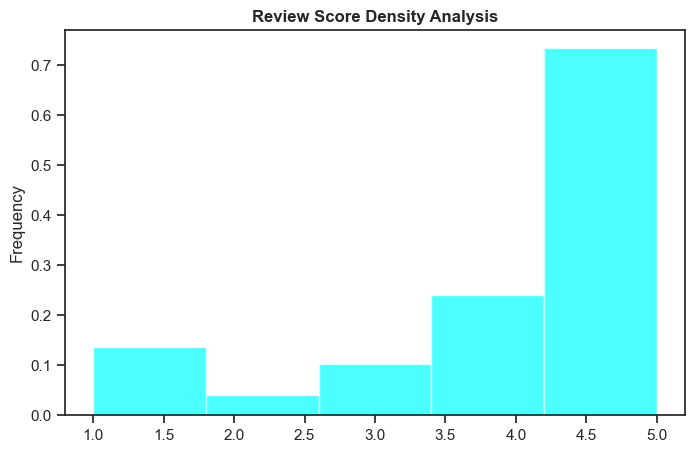

In [43]:
review_score = customer_orderitem_product_seller['review_score'].plot(
    kind='hist', 
    bins=5, 
    density=True, # Normalizes the data
    color='cyan', 
    alpha=0.7, 
    edgecolor='white',
    figsize=(8, 5)
)

plt.title('Review Score Density Analysis', fontweight='bold')
plt.show()



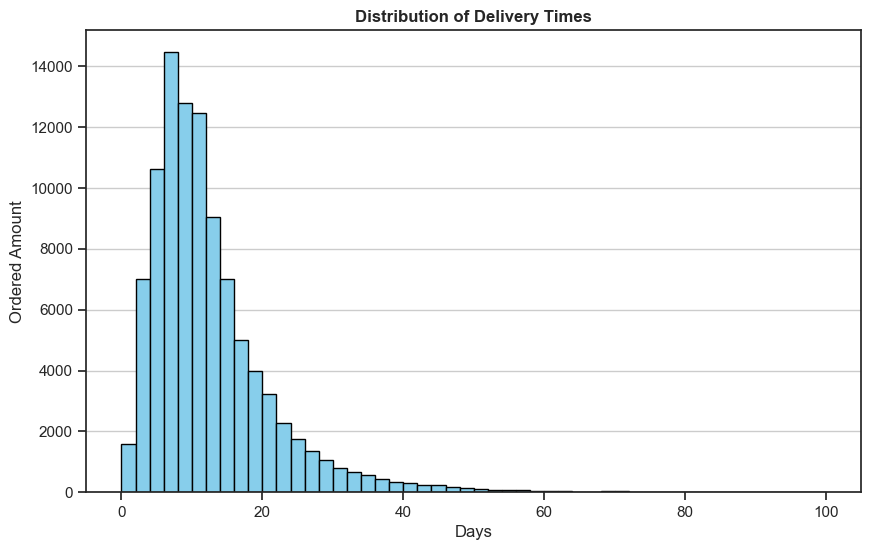

In [44]:
customer_orderitem_product_seller['delivery_time'].hist(
    bins=50, 
    range=(0, 100),
    color='skyblue', 
    edgecolor='black',
    figsize=(10, 6)
)

plt.title('Distribution of Delivery Times', fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Ordered Amount')
plt.grid(axis='x') # Keep only horizontal grid lines for a cleaner look
plt.show()

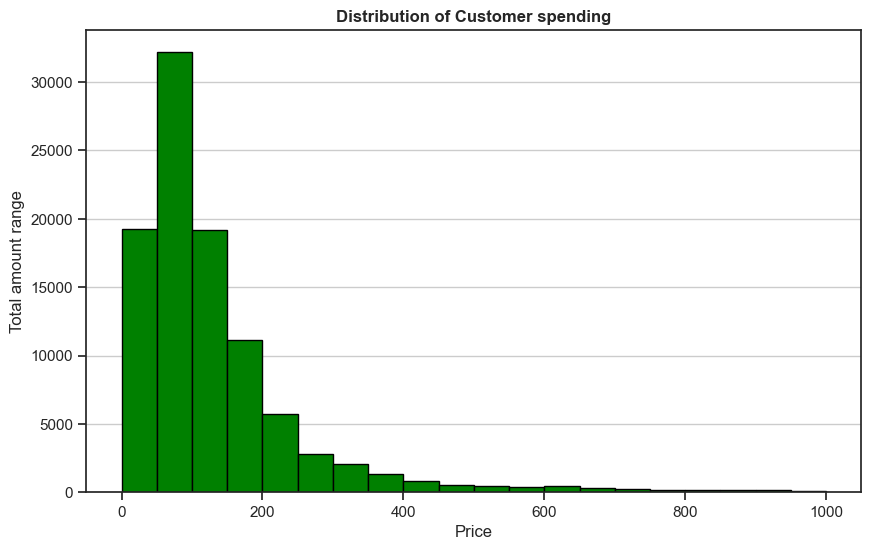

In [46]:
customer_orderitem_product_seller['customer_spend_value'].hist(
    bins=20,
    range=(0, 1000),
    color='green', 
    edgecolor='black',
    figsize=(10, 6)
)

plt.title('Distribution of Customer spending', fontweight='bold')
plt.xlabel('Price')
plt.ylabel('Total amount range')
plt.grid(axis='x')
plt.show()

**Box plots (outlier detection)**

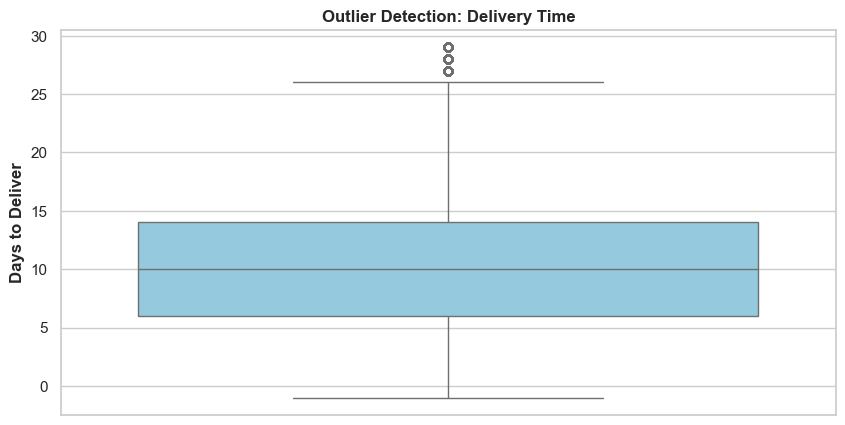

In [49]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Creating the boxplot
filtered_data = customer_orderitem_product_seller[customer_orderitem_product_seller['delivery_time'] < 30]

# Creating the boxplot - specify 'data' and 'y'
sns.boxplot(data=filtered_data, y='delivery_time', color='skyblue')

plt.title('Outlier Detection: Delivery Time', fontweight='bold')
plt.ylabel('Days to Deliver', fontweight='bold')
plt.show()

***Step 7: Business Insights and Recommendations***

**Identify top revenue-driving factors**

  product_category_name_english  customer_spend_value
9                          toys             538239.97
8                          auto             652336.54
7                    housewares             693883.16
6                    cool_stuff             696291.40
5               furniture_decor             759318.98
4         computers_accessories             906721.66
3                bed_bath_table            1117756.77
2                sports_leisure            1120192.91
1                 watches_gifts            1264823.21
0                 health_beauty            1369229.12


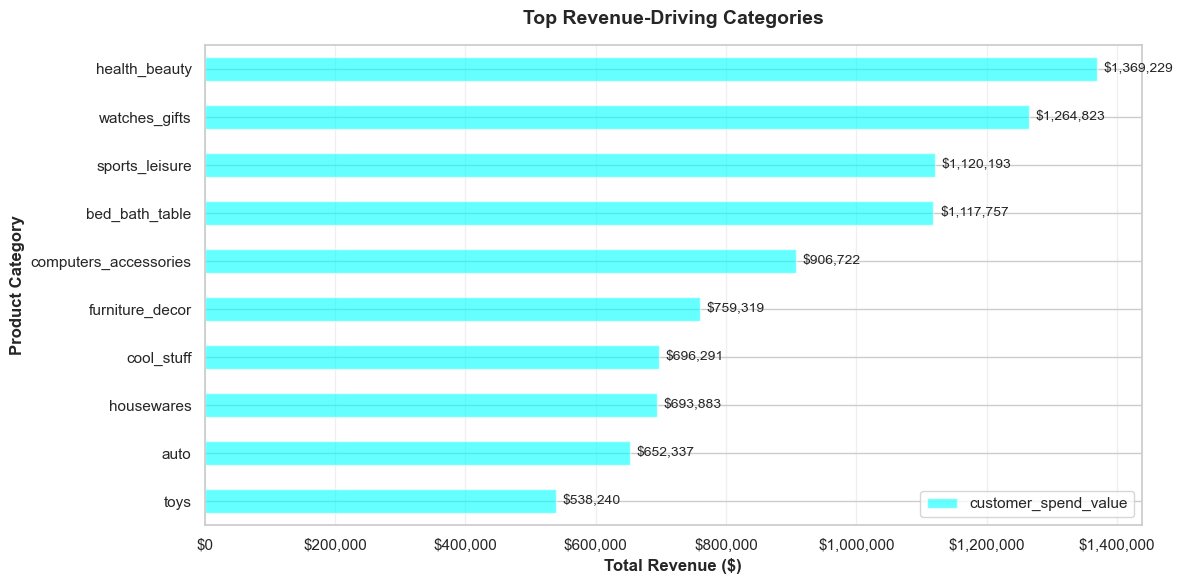

In [87]:
#cat_perfomance_revenue
print(top_categories)
top_categories = top_categories.sort_values(by='customer_spend_value',ascending=True)
fig, revenue_driving_ax = plt.subplots(figsize=(12, 6))

top_categories.plot(kind="barh", x='product_category_name_english', y='customer_spend_value',color="cyan", alpha=0.6, ax=revenue_driving_ax)


revenue_driving_ax.set_title(
    "Top Revenue-Driving Categories", fontsize=14, fontweight="bold", pad=15
)

revenue_driving_ax.set_xlabel("Total Revenue ($)", fontweight="bold")
revenue_driving_ax.set_ylabel("Product Category", fontweight="bold",rotation=90)
revenue_driving_ax.grid(True, axis="x", alpha=0.3)

# Add data labels inside/edge of the bars
revenue_driving_ax.bar_label(
    revenue_driving_ax.containers[0], fmt='${:,.0f}', padding=5, fontsize=10, fontweight="regular"
)

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()



**Highlight customer behavior patterns As peak sales months between Mar to AUG**

8876.0


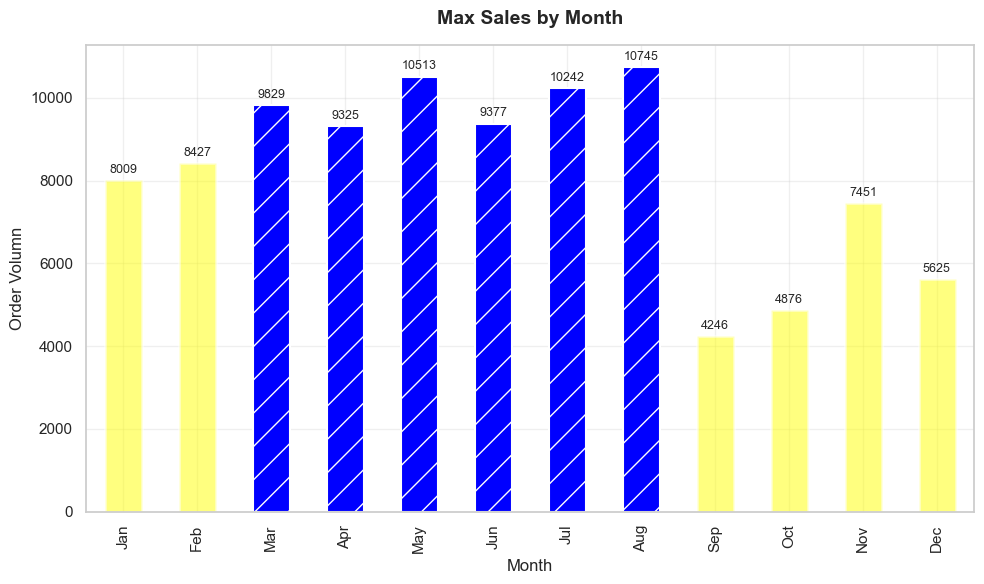

In [88]:
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

peak_sales_order = customer_orderitem_product_seller.groupby(customer_orderitem_product_seller['order_purchase_timestamp'].dt.month)['order_id'].count()
fig, maxsale = plt.subplots(figsize=(10,6))

#Calculating median as it consider as it will higher than mean and need to make point of consideration for max sale threshold.
median_sales_value = peak_sales_order.median();

maxsale = monthly_volumn_trand.plot(kind='bar', color='#FFFF01', linewidth=2, ax = maxsale, alpha=0.5)

# Option A: Dynamically find the highest bar index
#converting into list data recived is array and need to fetch the index for valuesthat matches criteria
peak_value_list = peak_sales_order.tolist()
for sale_values in peak_value_list:
    if sale_values > median_sales_value:
        high_blue_index = peak_value_list.index(sale_values)
        target_bar = maxsale.containers[0][high_blue_index]
        target_bar.set_color("blue")  
        target_bar.set_alpha(1.0)  
        target_bar.set_edgecolor("black")
        target_bar.set_linewidth(1.5)
        target_bar.set_hatch("/")  # Use '//' for diagonal lines, '||' for vertical lines
        target_bar.set_edgecolor("white")

maxsale.set_xlabel('Month')
maxsale.set_ylabel('Order Volumn')
maxsale.set_xticks(range(12))
#mapping month numbers with label
monthly_volumn_trand.index = monthly_volumn_trand.index.map(month_map)
maxsale.set_xticklabels(months_for_volumn_trend)
maxsale.bar_label(maxsale.containers[0], padding=3, fontsize=9,rotation=0)
maxsale.grid(True, alpha=0.3)
maxsale.set_title("Max Sales by Month", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

***Provide strategic recommendations***